正在讀取: rehab_dataset_keyframes_train_xyz.csv ...
正在讀取: rehab_dataset_keyframes_test_xyz.csv ...
主訓練資料筆數 (過濾後): 27360
獨立測試資料筆數: 5460
正在進行數據增強 (只針對訓練集)...
訓練集擴增後筆數: 43776
開始訓練...
Epoch 1/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7470 - loss: 0.6608 - val_accuracy: 0.9417 - val_loss: 0.1873
Epoch 2/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2243 - val_accuracy: 0.9728 - val_loss: 0.0834
Epoch 3/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9488 - loss: 0.1461 - val_accuracy: 0.9892 - val_loss: 0.0469
Epoch 4/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9614 - loss: 0.1086 - val_accuracy: 0.9887 - val_loss: 0.0362
Epoch 5/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9706 - loss: 0.0835 - val_accuracy: 0.9910 - val_loss: 0.0262
Epoch 6/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9735 - loss: 0.0752 - val_accuracy: 0.9949 - val_loss: 0.0160
Epoch 7/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/st

訓練完成！模型已儲存為: rehab_action_classifier_64_6.h5

正在使用 [獨立測試集] 進行最終評估...
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
正在執行幾何規則修正 (區分 拇指彎曲 vs 手指伸展)...
幾何規則已修正 404 筆資料。

--- 分類報告 (Conf=0.95, Dist=0.9) ---
                          precision    recall  f1-score   support

                Action 1     0.8879    0.9903    0.9363       720
                Action 2     0.9735    0.7803    0.8663       660
                Action 3     0.8267    0.9957    0.9034       690
                Action 4     0.8571    1.0000    0.9231       690
                Action 5     0.8108    1.0000    0.8955       510
                Action 6     0.9036    0.8597    0.8811       720
                Action 7     0.9442    0.9920    0.9675       750
Unknown (Threshold Fail)     0.5615    0.3042    0.3946       720

                accuracy                         0.8603      5460
               macro avg     0.8457    0.8653    0.8460      5460
            weighted avg     0.8462    0.8603    0.8438      5460



c:\Users\jxu27\anaconda3\envs\hand_recc\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jxu27\anaconda3\envs\hand_recc\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jxu27\anaconda3\envs\hand_recc\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jxu27\anaconda3\envs\hand_recc\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


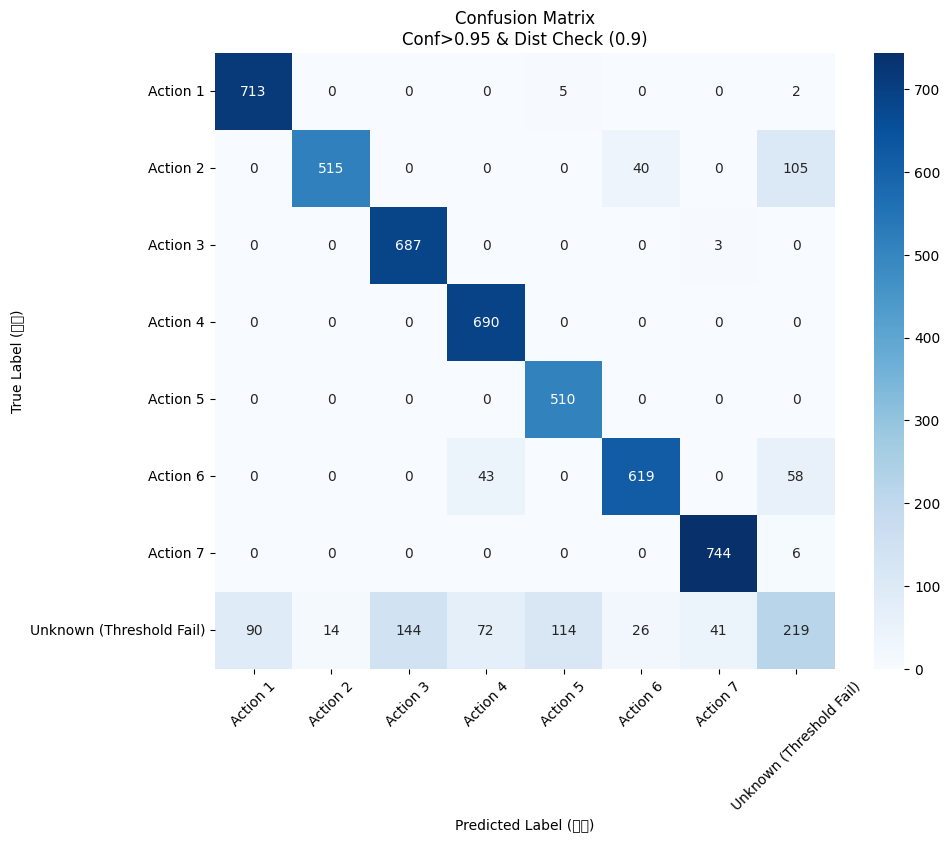

In [8]:
# 63
# 3與7的分辨
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- 繪圖與評估庫 ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
# ------------------

# ==========================================
# 1. 設定與資料讀取函式
# ==========================================
train_dataset_path = 'rehab_dataset_keyframes_train_xyz.csv'           # 主訓練檔
test_dataset_path = 'rehab_dataset_keyframes_test_xyz.csv' # 獨立測試檔
model_save_path = 'rehab_action_classifier_64_6.h5'
NUM_CLASSES = 7

# 修改 load_dataset 函式
def load_dataset(path):
    if not os.path.exists(path):
        print(f"錯誤：找不到檔案 {path}")
        exit()
        
    print(f"正在讀取: {path} ...")
    df = pd.read_csv(path, header=None)
    
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    
    # 邏輯：
    # 如果原始是 0 (非動作)，我們暫時標記為 7 (當作第8類，Unknown)
    # 如果原始是 1~7，我們減 1 變成 0~6
    y_transformed = np.where(y == 0, 7, y - 1)
        
    return X, y_transformed

# --- 讀取與過濾資料 ---
# 1. 讀取主資料
X_main, y_main = load_dataset(train_dataset_path)

# 2. 過濾掉標籤為 7 (Unknown) 的資料，僅訓練已知動作 0-6
# (注意：這裡修正了原本程式碼重複讀取導致過濾失效的問題)
train_mask = y_main != 7
X_main = X_main[train_mask]
y_main = y_main[train_mask]

# 3. 讀取獨立測試集 (測試集保留 7 用於驗證 Unknown 判斷)
X_test, y_test = load_dataset(test_dataset_path)

print(f"主訓練資料筆數 (過濾後): {len(X_main)}")
print(f"獨立測試資料筆數: {len(X_test)}")

# ==========================================
# 2. 資料處理與分割
# ==========================================

# 切分 20% 作為驗證用 (Validation Set)
X_train, X_val, y_train, y_val = train_test_split(
    X_main, y_main, test_size=0.2, random_state=42
)

# =========== 數據增強 (Data Augmentation) ===========
print("正在進行數據增強 (只針對訓練集)...")

def add_noise(data, noise_level=0.02):
    noise = np.random.normal(0, noise_level, data.shape)
    return data + noise

# 只對「訓練集」做增強
X_train_noise = add_noise(X_train)
X_train_augmented = np.vstack((X_train, X_train_noise))
y_train_augmented = np.concatenate((y_train, y_train))

print(f"訓練集擴增後筆數: {len(X_train_augmented)}")
# ===================================================

# ==========================================
# 3. 建立模型 (輸入層 63)
# ==========================================
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((63, )), 
    tf.keras.layers.Dense(256, activation='relu'), 
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 4. 開始訓練
# ==========================================
print("開始訓練...")
history = model.fit(
    X_train_augmented, y_train_augmented,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val), 
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=15, verbose=1, restore_best_weights=True)
    ]
)

# 存檔
model.save(model_save_path)
print(f"訓練完成！模型已儲存為: {model_save_path}")

# ==========================================
# 5. 模型評估 (信心度過濾 + 幾何規則修正)
# ==========================================

print("\n正在使用 [獨立測試集] 進行最終評估...")

# 1. 取得原始預測機率
y_pred_probs = model.predict(X_test)
y_pred_original = np.argmax(y_pred_probs, axis=1)
max_confidence = np.max(y_pred_probs, axis=1)

# --- 參數設定 ---
CONFIDENCE_THRESHOLD = 0.95  # 信心度門檻
THUMB_DIST_THRESHOLD = 0.9  # [幾何門檻] 拇指尖到小指根部的距離 (需要根據實際數據微調)

# 2. 第一層：應用信心度門檻
# 如果信心度 < 門檻，預測結果改為 7 (Unknown)
y_pred_final = np.where(max_confidence < CONFIDENCE_THRESHOLD, 7, y_pred_original)

# 3. 第二層：幾何規則修正 (解決 Action 3 與 Action 7 混淆)
# 轉換索引對照：
# 原始標籤 3 (拇指彎曲) -> 模型索引 2
# 原始標籤 7 (手指伸展) -> 模型索引 6
IDX_THUMB_FLEX = 2
IDX_SPREAD = 6

print("正在執行幾何規則修正 (區分 拇指彎曲 vs 手指伸展)...")

# 將測試集 Reshape 回 (N, 21, 3) 以便計算座標距離
X_test_reshaped = X_test.reshape(-1, 21, 3)
correction_count = 0

for i in range(len(y_pred_final)):
    current_pred = y_pred_final[i]
    
    # 只針對模型認為是 "Action 3" 或 "Action 7" 的結果進行複檢
    if current_pred == IDX_THUMB_FLEX or current_pred == IDX_SPREAD:
        
        # 取得關鍵點
        landmarks = X_test_reshaped[i]
        thumb_tip = landmarks[4]   # 拇指尖
        pinky_mcp = landmarks[17]  # 小指根部
        
        # 計算歐式距離
        dist = np.linalg.norm(thumb_tip - pinky_mcp)
        
        # 規則：距離大代表張開(7)，距離小代表彎曲(3)
        if dist > THUMB_DIST_THRESHOLD:
            # 應該是伸展 (Action 7)
            if current_pred != IDX_SPREAD:
                y_pred_final[i] = IDX_SPREAD
                correction_count += 1
        else:
            # 應該是拇指彎曲 (Action 3)
            if current_pred != IDX_THUMB_FLEX:
                y_pred_final[i] = IDX_THUMB_FLEX
                correction_count += 1

print(f"幾何規則已修正 {correction_count} 筆資料。")

# --- 繪圖與報表 ---

# 定義標籤名稱
target_names = [f'Action {i+1}' for i in range(NUM_CLASSES)] + ['Unknown (Threshold Fail)']

# A. 分類報告
print(f"\n--- 分類報告 (Conf={CONFIDENCE_THRESHOLD}, Dist={THUMB_DIST_THRESHOLD}) ---")
print(classification_report(y_test, y_pred_final, target_names=target_names, digits=4))

# B. 混淆矩陣
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Confusion Matrix\nConf>{CONFIDENCE_THRESHOLD} & Dist Check ({THUMB_DIST_THRESHOLD})')
plt.xlabel('Predicted Label (預測)')
plt.ylabel('True Label (真實)')
plt.xticks(rotation=45)
plt.show()


正在使用 [獨立測試集] 進行最終評估...
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
幾何規則已修正 401 筆易混淆資料 (3 vs 7)。

--- 分類報告 (Conf=0.95, Dist=0.95) ---
                          precision    recall  f1-score   support

                Action 1     0.8879    0.9903    0.9363       720
                Action 2     0.9735    0.7803    0.8663       660
                Action 3     0.8273    1.0000    0.9055       690
                Action 4     0.8571    1.0000    0.9231       690
                Action 5     0.8108    1.0000    0.8955       510
                Action 6     0.9036    0.8597    0.8811       720
                Action 7     0.9478    0.9920    0.9694       750
Unknown (Threshold Fail)     0.5615    0.3042    0.3946       720

                accuracy                         0.8608      5460
               macro avg     0.8462    0.8658    0.8465      5460
            weighted avg     0.8468    0.8608    0.8443      5460



c:\Users\jxu27\anaconda3\envs\hand_recc\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jxu27\anaconda3\envs\hand_recc\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jxu27\anaconda3\envs\hand_recc\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jxu27\anaconda3\envs\hand_recc\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


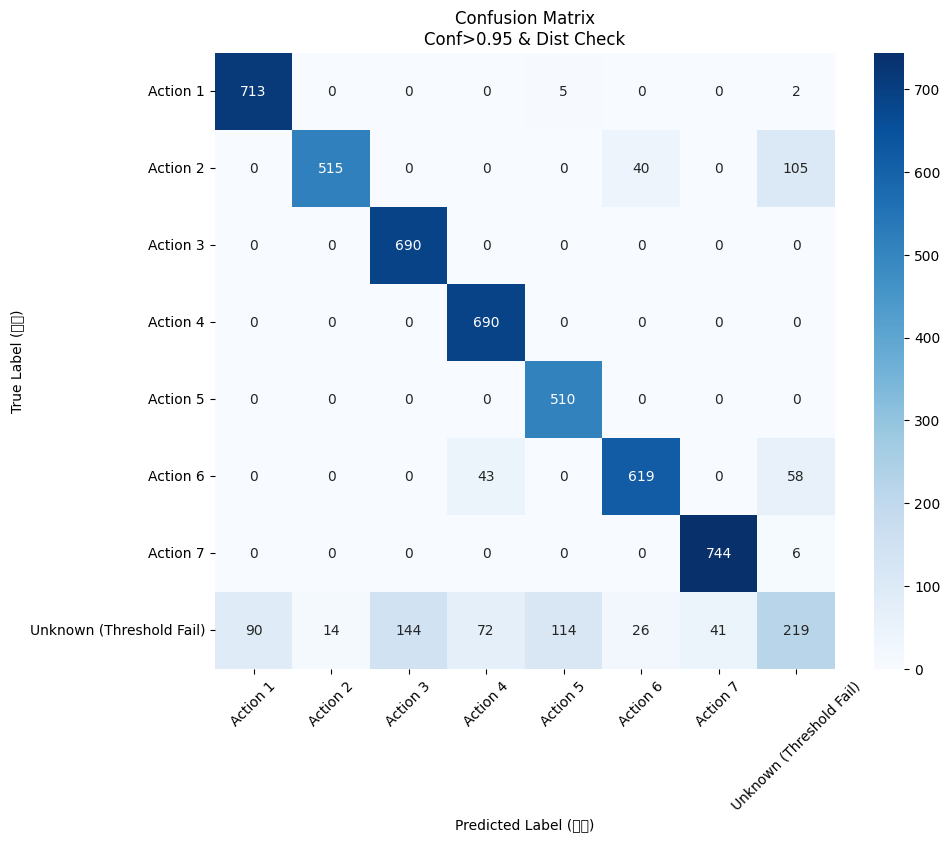

In [ ]:
# 調參 3+7
# ==========================================
# 5. 模型評估 (雙重過濾：信心度 + 幾何特徵修正)
# ==========================================

print("\n正在使用 [獨立測試集] 進行最終評估...")

# 1. 取得原始預測機率
y_pred_probs = model.predict(X_test)
y_pred_original = np.argmax(y_pred_probs, axis=1)
max_confidence = np.max(y_pred_probs, axis=1)

# --- 設定參數 ---
CONFIDENCE_THRESHOLD = 0.95  # 信心度門檻
THUMB_DIST_THRESHOLD = 0.95  # 幾何門檻 (拇指尖到小指根部的距離)，需微調！

# 2. 應用信心度門檻 (第一層過濾)
# 如果信心度不夠，先歸類為 7 (Unknown)
y_pred_final = np.where(max_confidence < CONFIDENCE_THRESHOLD, 7, y_pred_original)

# 3. 幾何特徵修正 (第二層過濾：專門解決 Action 3 與 Action 7 的混淆)
# 動作對應索引 (假設原標籤 1-7 被轉為 0-6)：
# 原 Action 3 (拇指彎曲) -> 模型索引 2
# 原 Action 7 (手指伸展) -> 模型索引 6
IDX_THUMB_FLEX = 2
IDX_SPREAD = 6

# 將扁平的特徵 (N, 63) 轉回 (N, 21, 3) 以便計算座標距離
X_test_reshaped = X_test.reshape(-1, 21, 3)

correction_count = 0 # 記錄修正了幾筆

for i in range(len(y_pred_final)):
    current_pred = y_pred_final[i]
    
    # 只針對被預測為 "拇指彎曲" 或 "伸展" 的資料進行複查
    if current_pred == IDX_THUMB_FLEX or current_pred == IDX_SPREAD:
        
        # 取得關鍵點座標
        landmarks = X_test_reshaped[i]
        thumb_tip = landmarks[4]   # 點4: 拇指尖
        pinky_mcp = landmarks[17]  # 點17: 小指根部
        
        # 計算歐式距離
        dist = np.linalg.norm(thumb_tip - pinky_mcp)
        
        # 幾何規則判斷
        if dist > THUMB_DIST_THRESHOLD:
            # 距離夠遠 -> 強制判定為 Action 7 (伸展)
            if current_pred != IDX_SPREAD:
                y_pred_final[i] = IDX_SPREAD
                correction_count += 1
        else:
            # 距離太近 -> 強制判定為 Action 3 (拇指彎曲)
            if current_pred != IDX_THUMB_FLEX:
                y_pred_final[i] = IDX_THUMB_FLEX
                correction_count += 1

print(f"幾何規則已修正 {correction_count} 筆易混淆資料 (3 vs 7)。")

# --- 後續繪圖與報表 (保持不變) ---

# 定義標籤名稱
target_names = [f'Action {i+1}' for i in range(NUM_CLASSES)] + ['Unknown (Threshold Fail)']

# A. 分類報告
print(f"\n--- 分類報告 (Conf={CONFIDENCE_THRESHOLD}, Dist={THUMB_DIST_THRESHOLD}) ---")
print(classification_report(y_test, y_pred_final, target_names=target_names, digits=4))

# B. 混淆矩陣
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Confusion Matrix\nConf>{CONFIDENCE_THRESHOLD} & Dist Check')
plt.xlabel('Predicted Label (預測)')
plt.ylabel('True Label (真實)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# inference.py
# 鏡頭 微調3+7
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp
from PIL import Image, ImageDraw, ImageFont

# ==========================================
# 0. 設定區 (參數微調區)
# ==========================================
# 請修改為你的模型路徑
MODEL_PATH = 'rehab_action_classifier_64_6.h5' 

# 【重要】如果你已經重新訓練並加入了 Z 軸，請設為 True
USE_Z_AXIS = True 

# 信心度門檻：低於此值顯示 "Unknown"
CONFIDENCE_THRESHOLD = 0.95

# 幾何門檻：區分 Action 3 (彎曲) 與 Action 7 (張開)
# 距離 > 此值 -> 判定為張開
# 距離 < 此值 -> 判定為彎曲
THUMB_DIST_THRESHOLD = 0.6 

GESTURE_LABELS = {
    0: "Hook 勾拳",             # 原 Action 1
    1: "Angry Fist 生氣握拳",    # 原 Action 2
    2: "Thumb Flex 拇指彎曲",    # 原 Action 3 
    3: "Straight Fist 直拳",     # 原 Action 4
    4: "The Duck 鴨子",          # 原 Action 5
    5: "Thumb In Fist 拇指內握", # 原 Action 6
    6: "Spread Hand 手指伸展",   # 原 Action 7
    7: "Unknown (信心不足)"       # 新增
}

# ==========================================
# 1. 載入模型與 MediaPipe
# ==========================================
try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"成功載入模型: {MODEL_PATH}")
    input_shape = model.input_shape[1]
    print(f"模型預期輸入維度: {input_shape}")
    
    if USE_Z_AXIS and input_shape == 42:
        print("警告：設定 USE_Z_AXIS=True，但模型是 2D。自動切換回 False。")
        USE_Z_AXIS = False
    elif not USE_Z_AXIS and input_shape == 63:
        print("警告：設定 USE_Z_AXIS=False，但模型是 3D。自動切換回 True。")
        USE_Z_AXIS = True

except Exception as e:
    print(f"載入模型失敗: {e}")
    exit()

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.5
)

# ==========================================
# 2. 核心：前處理 (保持一致)
# ==========================================
def normalize_landmarks(lm):
    if USE_Z_AXIS:
        wrist = np.array([lm[0].x, lm[0].y, lm[0].z])
        pts = np.array([[p.x, p.y, p.z] for p in lm])
    else:
        wrist = np.array([lm[0].x, lm[0].y])
        pts = np.array([[p.x, p.y] for p in lm])

    pts = pts - wrist
    middle_finger_len = np.linalg.norm(pts[9][:2]) 
    scale = max(middle_finger_len, 1e-6)
    pts = pts / scale

    angle = -np.arctan2(pts[9][1], pts[9][0])
    c, s = np.cos(angle), np.sin(angle)
    
    if USE_Z_AXIS:
        R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    else:
        R = np.array([[c, -s], [s, c]])
        
    pts = pts.dot(R.T)
    return pts

# ==========================================
# 3. 輔助：中文顯示
# ==========================================
def cv2_img_add_text(img, text, left, top, text_color=(0, 255, 0), text_size=20):
    if (isinstance(img, np.ndarray)):
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img)
    try:
        fontStyle = ImageFont.truetype("msjh.ttc", text_size, encoding="utf-8")
    except:
        fontStyle = ImageFont.load_default()
    draw.text((left, top), text, fill=text_color, font=fontStyle)
    return cv2.cvtColor(np.asarray(img), cv2.COLOR_RGB2BGR)

# ==========================================
# 4. 主迴圈
# ==========================================
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

print("程式啟動中... 按 'q' 鍵離開")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    frame = cv2.flip(frame, 1)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)
    
    if results.multi_hand_landmarks:
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
            
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            
            # 1. 取得正規化座標
            pts = normalize_landmarks(hand_landmarks.landmark)
            
            # 2. 左右手鏡像處理
            label_name = handedness.classification[0].label
            if label_name == "Left":
                pts[:, 0] = -pts[:, 0]

            # 3. 展平並預測
            input_data = pts.flatten().tolist()
            input_data = np.expand_dims(input_data, axis=0)
            
            prediction = model.predict(input_data, verbose=0)
            
            # 取得原始預測與信心度
            class_id = np.argmax(prediction)
            confidence = np.max(prediction)
            
            # ==========================================
            # 邏輯判斷區 (與訓練程式一致)
            # ==========================================
            final_class_id = class_id
            debug_msg = ""

            # A. 信心度過濾
            if confidence < CONFIDENCE_THRESHOLD:
                final_class_id = 7 # Unknown
            
            # B. 幾何規則修正 (針對 Action 3 與 7)
            # Index 2 = Thumb Flex, Index 6 = Spread Hand
            if final_class_id == 2 or final_class_id == 6:
                thumb_tip = pts[4]
                pinky_mcp = pts[17]
                
                # 計算距離
                dist = np.linalg.norm(thumb_tip - pinky_mcp)
                debug_msg = f"Dist: {dist:.3f}" # 顯示距離數值方便調試
                
                if dist > THUMB_DIST_THRESHOLD:
                    final_class_id = 6 # 強制判定為伸展
                else:
                    final_class_id = 2 # 強制判定為彎曲
            
            # ==========================================

            # 顯示結果
            result_text = GESTURE_LABELS.get(final_class_id, "Unknown")
            
            # 顏色邏輯：正常綠色，低信心或 Unknown 紅色
            if final_class_id == 7:
                color = (0, 0, 255) # 紅色
                display_text = f"Unknown ({confidence:.2f})"
            else:
                color = (0, 255, 0) # 綠色
                display_text = f"{result_text} ({confidence:.2f}) {debug_msg}"

            # 取得文字座標
            text_x = int(hand_landmarks.landmark[0].x * frame.shape[1])
            text_y = int(hand_landmarks.landmark[0].y * frame.shape[0])
            
            frame = cv2_img_add_text(frame, display_text, text_x + 10, text_y - 40, color, 30)

    cv2.imshow('Rehab Gesture Recognition', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

成功載入模型: rehab_action_classifier_64_6.h5
模型預期輸入維度: 63
程式啟動中... 按 'q' 鍵離開


In [2]:
# inference.py
# 鏡頭 微調3+7 2+6
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp
from PIL import Image, ImageDraw, ImageFont

# ==========================================
# 0. 設定區 (參數微調區)
# ==========================================
# 請修改為你的模型路徑
MODEL_PATH = 'rehab_action_classifier_64_5.h5' 

# 【重要】必須設為 True 才能使用深度判斷
USE_Z_AXIS = True 

# 信心度門檻
CONFIDENCE_THRESHOLD = 0.95

# --- [幾何門檻 1] 拇指彎曲 vs 手指伸展 ---
# 距離 > 此值 -> 判定為張開
# 距離 < 此值 -> 判定為彎曲
# 建議值約 0.15 ~ 0.3 (視你的正規化縮放而定，0.6 可能有點太大)
THUMB_DIST_THRESHOLD = 0.6 

# --- [幾何門檻 2] 拇指外握 vs 拇指內握 (新增) ---
# 這是 "拇指尖 Z" - "食指根部 Z" 的差值
# 拇指在外：拇指較凸 (靠近鏡頭)，Z值較小 -> 差值為負 (例如 -0.05)
# 拇指在內：拇指被包住 (遠離鏡頭)，Z值較大 -> 差值接近 0 或正數
# 建議值：-0.02 (比這個值更負就是外握，否則內握)
Z_DIFF_THRESHOLD = -0.02

GESTURE_LABELS = {
    0: "Hook 勾拳",             
    1: "Angry Fist 生氣握拳",    # [拇指在外]
    2: "Thumb Flex 拇指彎曲",    
    3: "Straight Fist 直拳",     
    4: "The Duck 鴨子",          
    5: "Thumb In Fist 拇指內握", # [拇指在內]
    6: "Spread Hand 手指伸展",   
    7: "Unknown (信心不足)"       
}

# ==========================================
# 1. 載入模型與 MediaPipe
# ==========================================
try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"成功載入模型: {MODEL_PATH}")
    input_shape = model.input_shape[1]
    
    if USE_Z_AXIS and input_shape == 42:
        print("警告：設定 USE_Z_AXIS=True，但模型是 2D。自動切換回 False。")
        USE_Z_AXIS = False
    elif not USE_Z_AXIS and input_shape == 63:
        print("警告：設定 USE_Z_AXIS=False，但模型是 3D。自動切換回 True。")
        USE_Z_AXIS = True

except Exception as e:
    print(f"載入模型失敗: {e}")
    exit()

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.5
)

# ==========================================
# 2. 核心：前處理
# ==========================================
def normalize_landmarks(lm):
    if USE_Z_AXIS:
        wrist = np.array([lm[0].x, lm[0].y, lm[0].z])
        pts = np.array([[p.x, p.y, p.z] for p in lm])
    else:
        wrist = np.array([lm[0].x, lm[0].y])
        pts = np.array([[p.x, p.y] for p in lm])

    pts = pts - wrist
    middle_finger_len = np.linalg.norm(pts[9][:2]) 
    scale = max(middle_finger_len, 1e-6)
    pts = pts / scale

    angle = -np.arctan2(pts[9][1], pts[9][0])
    c, s = np.cos(angle), np.sin(angle)
    
    if USE_Z_AXIS:
        R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    else:
        R = np.array([[c, -s], [s, c]])
        
    pts = pts.dot(R.T)
    return pts

# ==========================================
# 3. 輔助：中文顯示
# ==========================================
def cv2_img_add_text(img, text, left, top, text_color=(0, 255, 0), text_size=20):
    if (isinstance(img, np.ndarray)):
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img)
    try:
        fontStyle = ImageFont.truetype("msjh.ttc", text_size, encoding="utf-8")
    except:
        fontStyle = ImageFont.load_default()
    draw.text((left, top), text, fill=text_color, font=fontStyle)
    return cv2.cvtColor(np.asarray(img), cv2.COLOR_RGB2BGR)

# ==========================================
# 4. 主迴圈
# ==========================================
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

print("程式啟動中... 按 'q' 鍵離開")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    frame = cv2.flip(frame, 1)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)
    
    if results.multi_hand_landmarks:
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
            
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            
            # 1. 前處理
            pts = normalize_landmarks(hand_landmarks.landmark)
            
            # 2. 鏡像修正
            label_name = handedness.classification[0].label
            if label_name == "Left":
                pts[:, 0] = -pts[:, 0]

            # 3. 預測
            input_data = pts.flatten().tolist()
            input_data = np.expand_dims(input_data, axis=0)
            
            prediction = model.predict(input_data, verbose=0)
            class_id = np.argmax(prediction)
            confidence = np.max(prediction)
            
            # ==========================================
            # 邏輯判斷區
            # ==========================================
            final_class_id = class_id
            debug_msg = ""

            # --- A. 信心度過濾 ---
            if confidence < CONFIDENCE_THRESHOLD:
                final_class_id = 7 # Unknown
            
            # --- B. 規則 1: 拇指彎曲 vs 手指伸展 ---
            # Index 2 (Thumb Flex) vs Index 6 (Spread Hand)
            elif final_class_id == 2 or final_class_id == 6:
                thumb_tip = pts[4]
                pinky_mcp = pts[17]
                dist = np.linalg.norm(thumb_tip - pinky_mcp)
                debug_msg = f"Dist: {dist:.3f}" 
                
                if dist > THUMB_DIST_THRESHOLD:
                    final_class_id = 6 
                else:
                    final_class_id = 2 

            # --- C. 規則 2: 拇指外握(生氣) vs 拇指內握 ---
            # Index 1 (Angry Fist) vs Index 5 (Thumb In Fist)
            # 也可以把 Index 0 (Hook) 加進來一起判斷，如果 Hook 也是外握的話
            elif final_class_id == 1 or final_class_id == 5 or final_class_id == 0:
                thumb_tip = pts[4]   # 拇指尖
                index_pip = pts[6]   # 食指第二關節
                
                # 計算 Z 軸差值 (負越小代表越凸出/靠近鏡頭)
                z_diff = thumb_tip[2] - index_pip[2]
                debug_msg = f"Z-Diff: {z_diff:.3f}"

                # 判定邏輯
                if z_diff < Z_DIFF_THRESHOLD:
                    # 拇指明顯在外
                    if final_class_id == 5: # 如果原本猜內握，強制改成外握(生氣)
                        final_class_id = 1 
                else:
                    # 拇指不夠凸出 (被包住或平行) -> 判定為內握
                    final_class_id = 5 

            # ==========================================

            # 顯示
            result_text = GESTURE_LABELS.get(final_class_id, "Unknown")
            
            if final_class_id == 7:
                color = (0, 0, 255) 
                display_text = f"Unknown ({confidence:.2f})"
            else:
                color = (0, 255, 0)
                display_text = f"{result_text} ({confidence:.2f}) {debug_msg}"

            text_x = int(hand_landmarks.landmark[0].x * frame.shape[1])
            text_y = int(hand_landmarks.landmark[0].y * frame.shape[0])
            
            frame = cv2_img_add_text(frame, display_text, text_x + 10, text_y - 40, color, 30)

    cv2.imshow('Rehab Gesture Recognition', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

成功載入模型: rehab_action_classifier_64_5.h5
程式啟動中... 按 'q' 鍵離開
